In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

adata = ad.read_h5ad("../data_interim/final_filtered.h5ad")

In [2]:
sc.pp.highly_variable_genes(adata,layer="counts",flavor="seurat_v3",n_top_genes=3000)

In [3]:
sc.tl.pca(adata,n_comps=50,svd_solver='arpack',mask_var='highly_variable')

In [4]:
sc.pp.neighbors(adata, n_neighbors=15,n_pcs=50,random_state=2026)

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
sc.tl.leiden(adata,resolution=0.5,random_state=2026,flavor="igraph",n_iterations=2,directed=False)
adata.obs["leiden"] = adata.obs["leiden"].copy()
adata.uns["leiden"] = adata.uns["leiden"].copy()
adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()

In [6]:
sc.tl.paga(adata,groups="leiden")
sc.pl.paga(adata,plot=False)

In [7]:
sc.tl.umap(adata, min_dist=0.3,init_pos='paga')

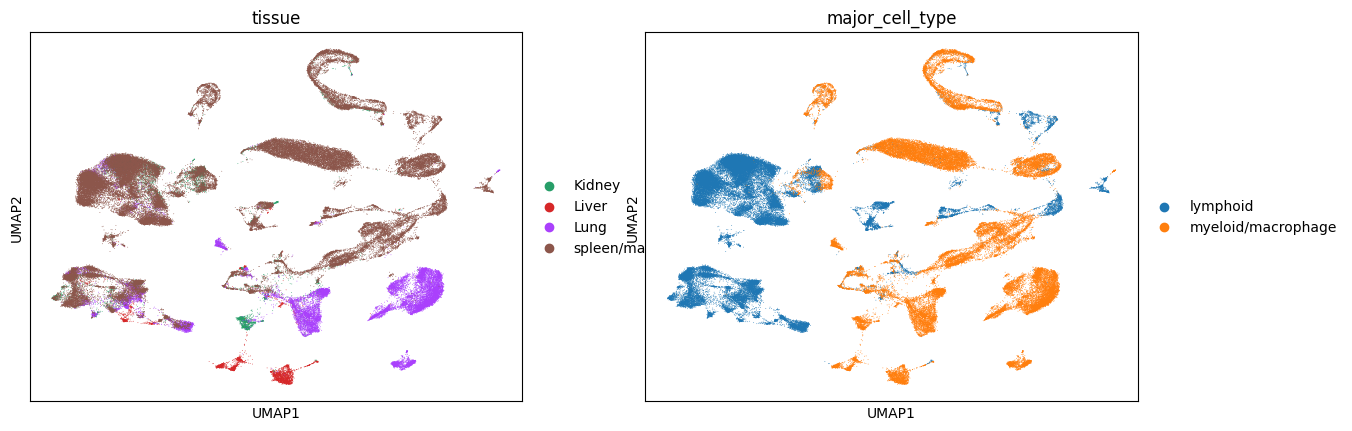

In [8]:
sc.pl.umap(adata, color=['tissue', 'major_cell_type'])

In [9]:
adata.obs["age_group"] = np.nan
adata.obs["age"] = (
    adata.obs["age"]
    .str.replace("m", "", regex=False)
    .str.strip()
    .astype(int)
)
for idx, age in adata.obs["age"].items():
    if 1 <= age <= 5:
        adata.obs.loc[idx, "age_group"] = "young"
    elif 6 <= age <= 21:
        adata.obs.loc[idx, "age_group"] = "middle"
    elif 22 <= age <= 30:
        adata.obs.loc[idx, "age_group"] = "old"

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_18320\44239996.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'middle' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[idx, "age_group"] = "middle"


In [10]:
print(pd.crosstab(adata.obs["tissue"],adata.obs["age_group"]))

age_group      middle    old  young
tissue                             
Kidney            746   6310    296
Liver             501   2012    938
Lung             5075  10435   3543
spleen/marrow   20315  26735  14662


In [11]:
adata.write_h5ad('../data_processed/final_data.h5ad')